# Ranging and Ransac

We'll use the following imports:

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import linear_model

If you get an error from importing sklearn, then you will have to install it using:
conda install scikit-learn

For the exercise we will be using the data taken from a lidar by a robot in a hallway. The data is saved in `laser.csv` and we can import this in Python using numpy as such:

In [2]:
laser = np.genfromtxt('laser.csv', delimiter=',')

The file contains only a single rotation of the lidar. You can open the file in any text editor to get a look at the data. Each number in the file is the distance measured in meters. The lidar starts measuring at 135 degrees and ends at -135 degrees and it rotates the same amount between each measurement. 

## Exercise 3.1
Convert the data in the csv file to x and y coordinates in a Carthesian coordinate system and plot the result using matplotlib.

Hint: Use [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) instead of plt.plot in order to show every measurement as a point. 

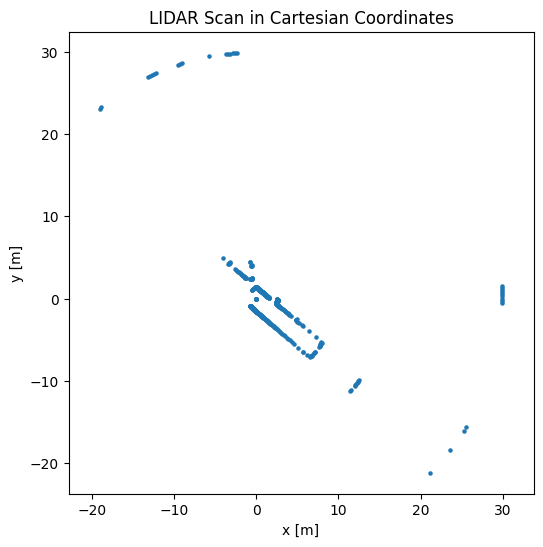

In [3]:
# Convert to x and y coordinates
import numpy as np
import matplotlib.pyplot as plt

# Load lidar data
laser = np.genfromtxt('laser.csv', delimiter=',')

# Convert from polar (r, θ) to Cartesian (x, y)
angles = np.linspace(np.deg2rad(135), np.deg2rad(-135), len(laser))
x = laser * np.cos(angles)
y = laser * np.sin(angles)

# Plot the points
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5)
plt.axis('equal')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('LIDAR Scan in Cartesian Coordinates')
plt.show()


## Exercise 3.2

We would like to locate one of the walls in the dataset. To do so we will use [Ransac](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RANSACRegressor.html) to fine the best line fit in the noisy data. A Ransac regressor is initialized the following way using sklearn:

In [4]:
ransac = linear_model.RANSACRegressor()

Now that we have our Ransac regressor we can fit it to a dataset (x,y):

In [5]:
# Fit data
from sklearn import linear_model

X = x.reshape(-1, 1)   # sklearn expects 2D array
ransac = linear_model.RANSACRegressor(linear_model.LinearRegression(),
                                      residual_threshold=0.05,
                                      random_state=0)
ransac.fit(X, y)


,estimator,LinearRegression()
,min_samples,None
,residual_threshold,0.05
,is_data_valid,None
,is_model_valid,None
,max_trials,100
,max_skips,inf
,stop_n_inliers,inf
,stop_score,inf
,stop_probability,0.99
,loss,'absolute_error'


Finally, to get the fitted line we can use the predict function. As an argument this takes the x values in which the line will be predicted:

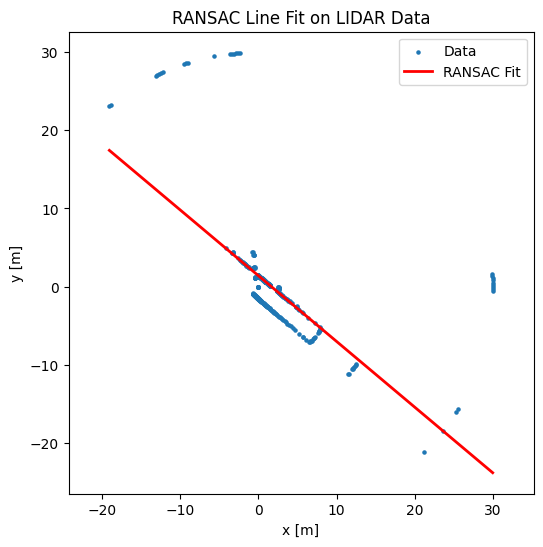

In [6]:
# Predict line
xx = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
yy = ransac.predict(xx)

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5, label='Data')
plt.plot(xx, yy, 'r', lw=2, label='RANSAC Fit')
plt.axis('equal')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('RANSAC Line Fit on LIDAR Data')
plt.legend()
plt.show()


Plot the line on top of the scatterplot from before to see the fit.

## Exercise 3.3

To see which data points were used to make the line fit and which were deemed outliers, we can use the function ransac.inlier_mask_

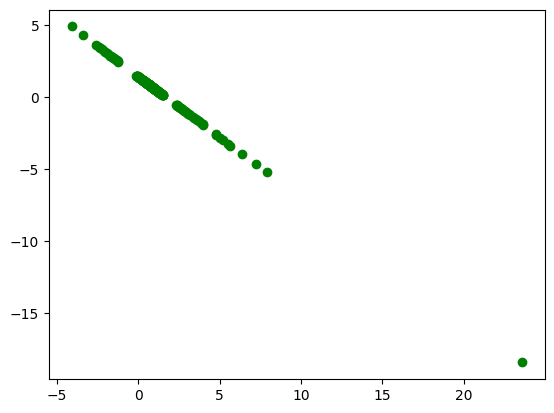

In [7]:
plt.scatter(x[ransac.inlier_mask_], y[ransac.inlier_mask_], color='green')

Find the second hallway wall using another Ransac fit and plot it together with the data points and the first ransac fit.

Hint: Use the outliers from the first Ransac.

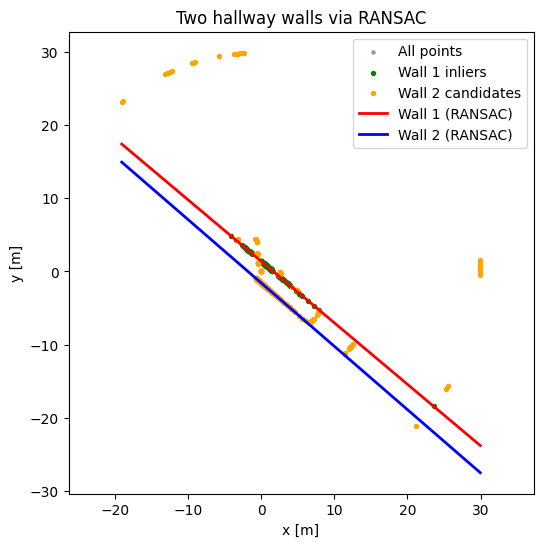

In [8]:
ransac2 = linear_model.RANSACRegressor()

# Find the second hallway wall
# Outliers from the first RANSAC
out = ~ransac.inlier_mask_
X2 = x[out].reshape(-1, 1)
y2 = y[out]

# Second RANSAC on outliers
ransac2 = linear_model.RANSACRegressor(linear_model.LinearRegression(),
                                       residual_threshold=0.05, random_state=1)
ransac2.fit(X2, y2)
yy2 = ransac2.predict(xx)  # use same xx as before

# Plot data + both walls
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5, c='0.6', label='All points')
plt.scatter(x[ransac.inlier_mask_], y[ransac.inlier_mask_], s=8, c='g', label='Wall 1 inliers')
plt.scatter(x[out], y[out], s=8, c='orange', label='Wall 2 candidates')
plt.plot(xx, ransac.predict(xx), 'r', lw=2, label='Wall 1 (RANSAC)')
plt.plot(xx, yy2, 'b', lw=2, label='Wall 2 (RANSAC)')
plt.axis('equal'); plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.title('Two hallway walls via RANSAC')
plt.legend(); plt.show()
